# Human-skill structure — correlation & multivariate analysis

Reads `skill-metrics.csv` (from `analyze_skills.py`) and explores how the human-curated **skill-structure metrics** relate to each other, to task difficulty, and to the `structure_class` axis used for stratified sampling in the *human-curated vs AIP-from-curated* study.

1. **Correlation heatmap** (Spearman — robust to heavy-tailed LoC counts).
2. **Pairwise scatter + regression matrix** across the key structure metrics.
3. The same matrix **colored by `structure_class`** to see how prose-only / mixed / script-heavy groups separate.

## Metrics dictionary

Columns in `skill-metrics.csv` (one row per task), produced by `analyze_skills.py` from each task's human-curated skills under `vendor/skillsbench/tasks/<task>/environment/skills/`.

| column | type | meaning |
|---|---|---|
| `task` | str | task name (dir under `vendor/skillsbench/tasks/`) |
| `difficulty` | cat | `easy` / `medium` / `hard`, from `task.toml` (human-estimated, not model difficulty) |
| `category` | cat | controlled domain category, from `task.toml` |
| `description` | str | first sentence of the task's `instruction.md` |
| `structure_class` | cat | **AIP-upside axis** — `prose-only` (no scripts; highest upside), `mixed` (scripts < prose), `script-heavy` (scripts ≥ prose; lowest upside), `none` (no curated skill) |
| `n_skills` | int | number of curated skill dirs (each with a `SKILL.md`) bundled with the task |
| `skill_names` | str | `;`-joined skill dir names |
| `skill_md_loc` | int | total lines across all `SKILL.md` files — the procedure *prose* |
| `n_scripts` | int | count of executable files (under `scripts/`, or code extensions `.py/.sh/.js/...`) |
| `script_loc` | int | total lines across those scripts — the *executable* knowledge |
| `n_refs` | int | count of reference docs (`references/`, other `.md`/`.txt`) |
| `ref_loc` | int | total lines across reference docs |
| `n_assets` | int | non-code, non-doc bundled files (data, images, templates) |
| `prose_loc` | int | `skill_md_loc + ref_loc` — total human-readable text the agent must absorb |
| `prose_to_code_ratio` | float | `prose_loc / script_loc` — high = prose-heavy (more AIP upside); blank when `script_loc == 0` |
| `total_files` | int | all files in the task's skill set |
| `total_kb` | float | total size of the skill set, KB |

**Derived in this notebook:** `difficulty_ord` = `easy`→0, `medium`→1, `hard`→2 (ordinal encoding so difficulty can enter the correlation matrix).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")

csv = Path("skill-metrics.csv")
if not csv.exists():
    csv = Path("skill-analysis/skill-metrics.csv")
df = pd.read_csv(csv)
df["difficulty_ord"] = df["difficulty"].map({"easy": 0, "medium": 1, "hard": 2})

metrics = ["n_skills", "skill_md_loc", "n_scripts", "script_loc",
           "n_refs", "ref_loc", "n_assets", "prose_loc", "total_files", "difficulty_ord"]
num = df[metrics].apply(pd.to_numeric, errors="coerce")
print(f"{len(df)} tasks loaded")
num.describe().T.round(1)

95 tasks loaded


,count,mean,std,min,25%,50%,75%,max
n_skills,95.0,2.7,1.5,1.0,1.0,2.0,3.0,7.0
skill_md_loc,95.0,541.0,484.2,20.0,249.0,373.0,638.5,2190.0
n_scripts,95.0,2.5,5.3,0.0,0.0,0.0,3.0,39.0
script_loc,95.0,517.3,1371.4,0.0,0.0,0.0,284.0,9384.0
n_refs,95.0,2.9,7.9,0.0,0.0,0.0,3.0,50.0
ref_loc,95.0,649.1,1615.5,0.0,0.0,0.0,632.5,10894.0
n_assets,95.0,1.9,9.7,0.0,0.0,0.0,0.0,78.0
prose_loc,95.0,1190.1,1788.8,20.0,275.0,471.0,1298.0,11494.0
total_files,95.0,10.0,17.5,1.0,3.0,5.0,10.0,136.0
difficulty_ord,95.0,1.3,0.6,0.0,1.0,1.0,2.0,2.0


## Correlation heatmap

Spearman rank correlation — the LoC/count metrics are heavy-tailed (a few tasks carry thousands of script lines, many carry zero), so rank correlation is more meaningful than Pearson. `difficulty_ord` (easy=0, medium=1, hard=2) is included to check whether structure tracks difficulty or is an independent axis.

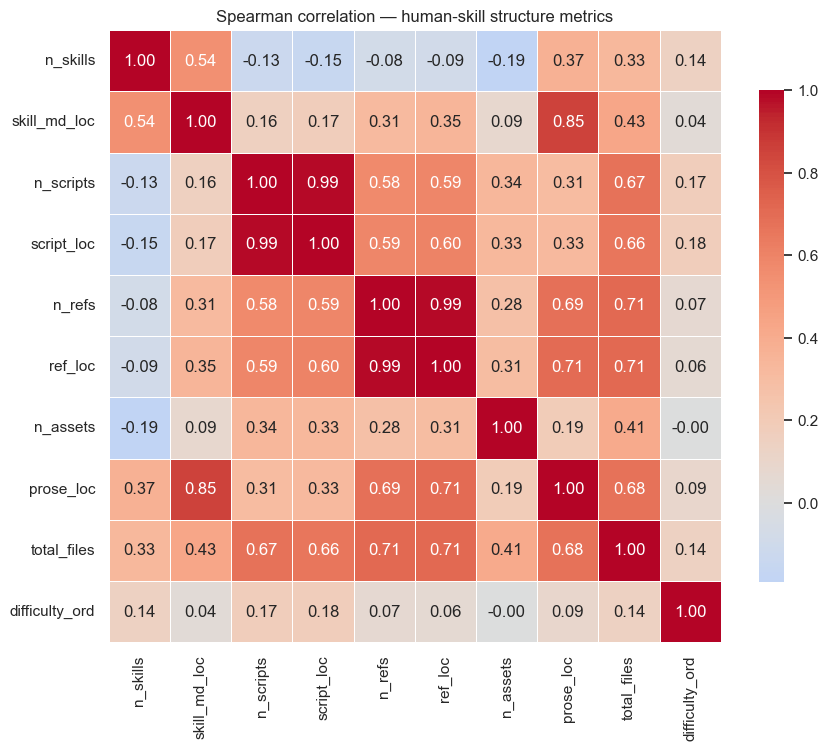

In [2]:
corr = num.corr(method="spearman")
plt.figure(figsize=(9, 7.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Spearman correlation — human-skill structure metrics")
plt.tight_layout()
plt.show()

## Pairwise scatter + regression matrix

Each off-diagonal panel: a scatter of two metrics with an OLS regression line; diagonals are per-metric KDEs. Focused on the structure metrics most relevant to the AIP-upside axis.

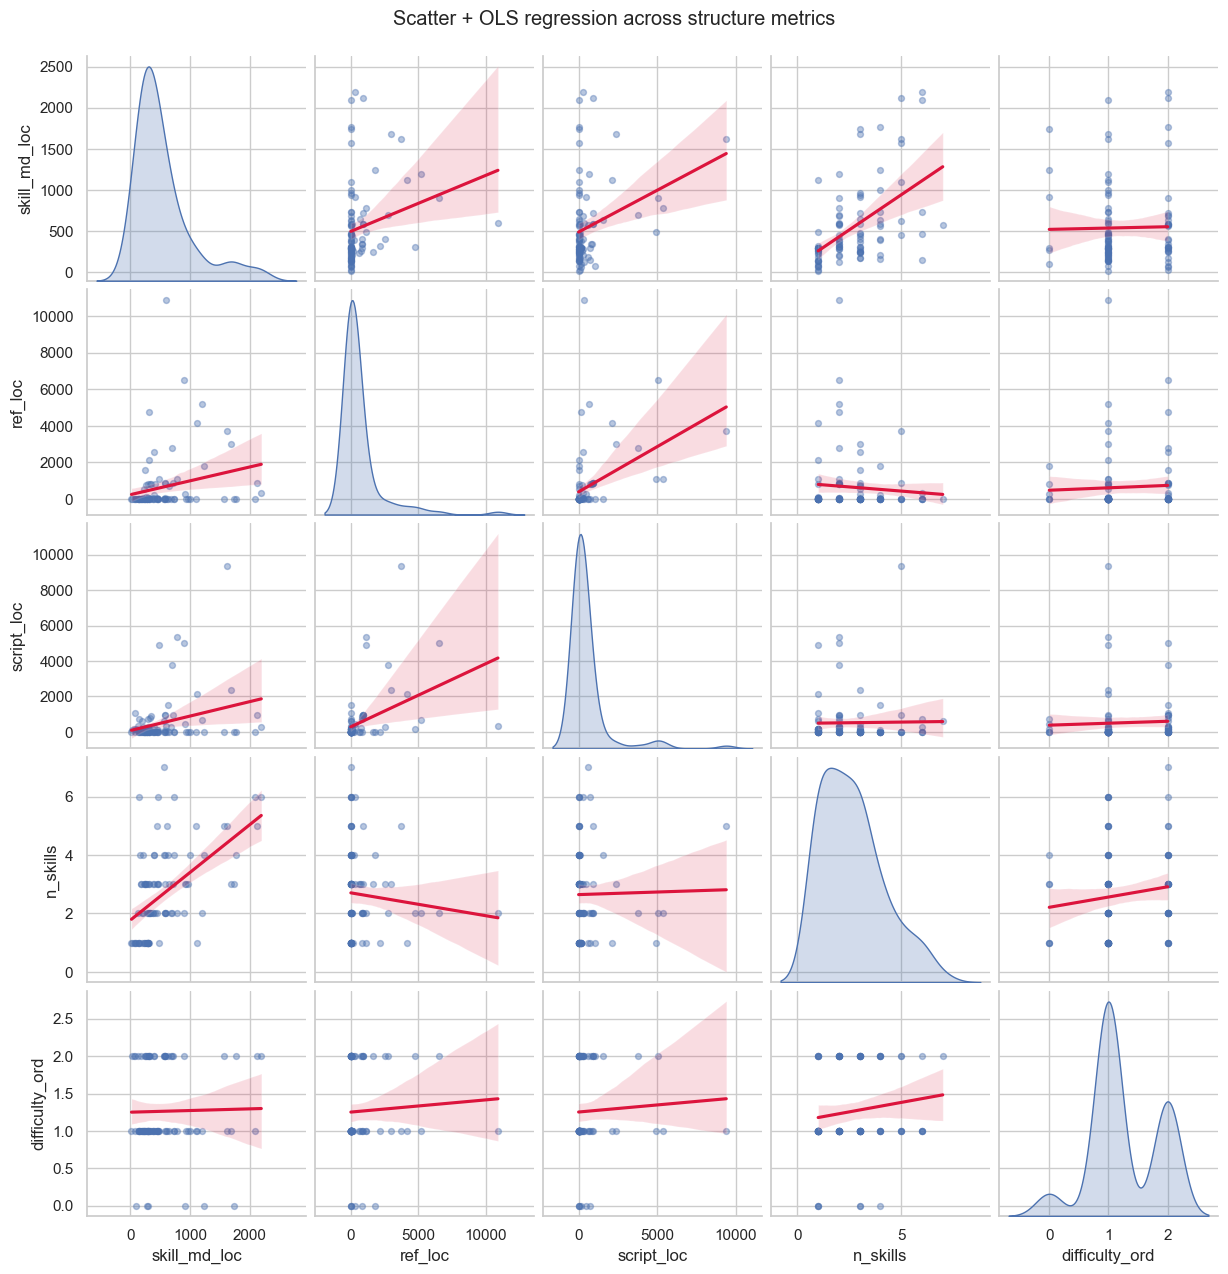

In [3]:
pair_metrics = ["skill_md_loc", "ref_loc", "script_loc", "n_skills", "difficulty_ord"]
g = sns.pairplot(num[pair_metrics].dropna(), kind="reg", diag_kind="kde",
                 plot_kws={"line_kws": {"color": "crimson"},
                           "scatter_kws": {"alpha": 0.4, "s": 18}})
g.figure.suptitle("Scatter + OLS regression across structure metrics", y=1.02)
plt.show()

## Colored by `structure_class`

How the prose-only / mixed / script-heavy groups separate in metric space — the basis for picking eval tasks that span the AIP-upside gradient.

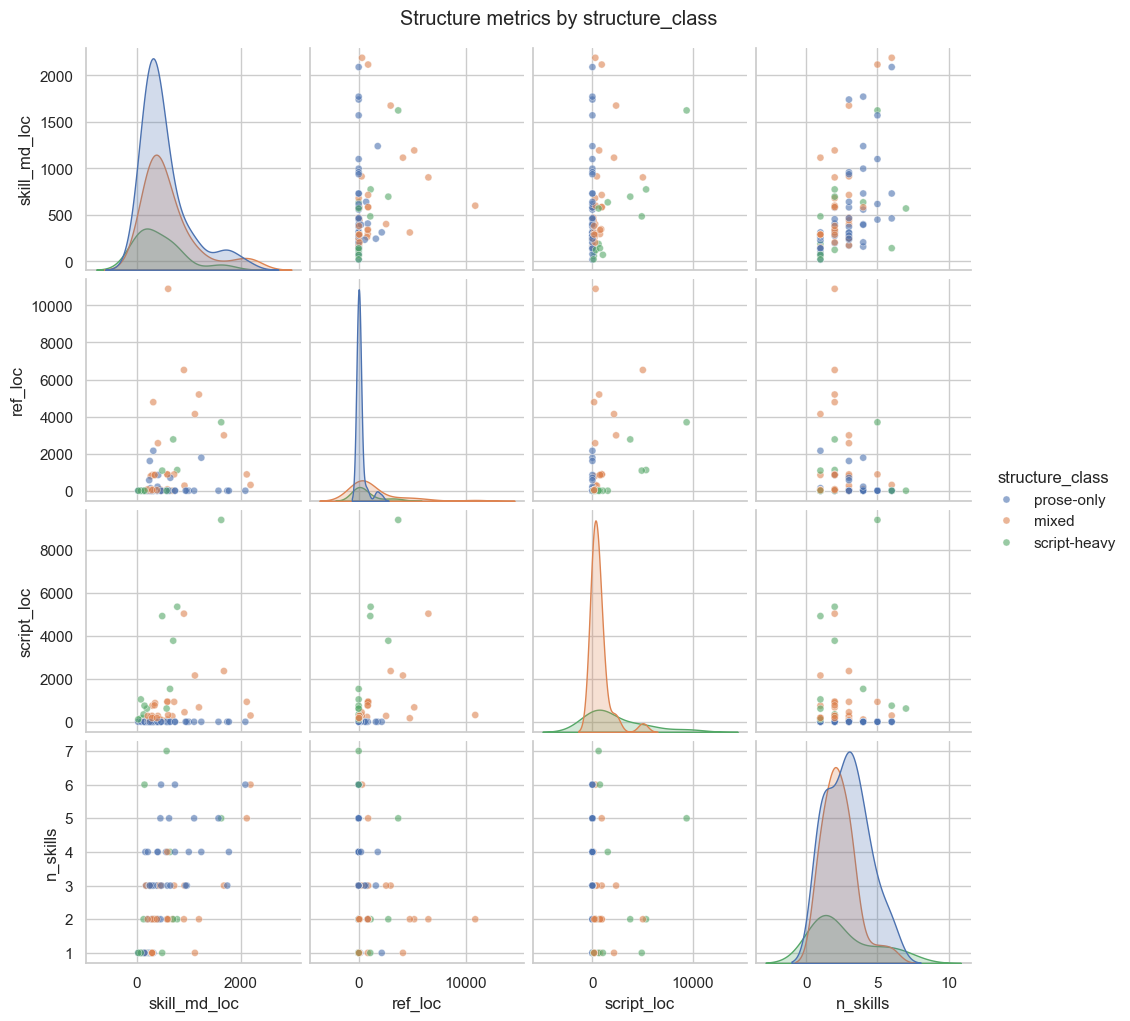

In [4]:
df_num = df.assign(**{m: num[m] for m in pair_metrics})
g2 = sns.pairplot(df_num, vars=["skill_md_loc", "ref_loc", "script_loc", "n_skills"],
                  hue="structure_class", hue_order=["prose-only", "mixed", "script-heavy"],
                  diag_kind="kde", plot_kws={"alpha": 0.6, "s": 26})
g2.figure.suptitle("Structure metrics by structure_class", y=1.02)
plt.show()

## Hypothesized AIP-upside drivers, by difficulty

Working hypothesis: AIP-from-curated's benefit over human-curated is driven by **how much unstructured prose** the human skill carries — i.e. `prose_loc`, `prose_to_code_ratio`, and `skill_md_loc`. (Consistent with the eval-3med deep dives: drone was prose-only → largest gain; crystallographic was prose-heavy → consistency gain.)

> **Caveat:** we can't yet *correlate* these to measured AIP-cur benefit — that needs a per-task `(aip_cur − human)` delta across many tasks, and we have eval data for only 3 so far. These box plots instead show how the candidate driver metrics **distribute within each difficulty tier**, to confirm there's range to sample (i.e. you can pick prose-heavy *and* prose-light tasks at every difficulty). y-axis is log-scaled (the metrics are heavy-tailed). `prose_to_code_ratio` excludes the 50 prose-only tasks (no scripts → ratio undefined; they're the extreme high end by definition).

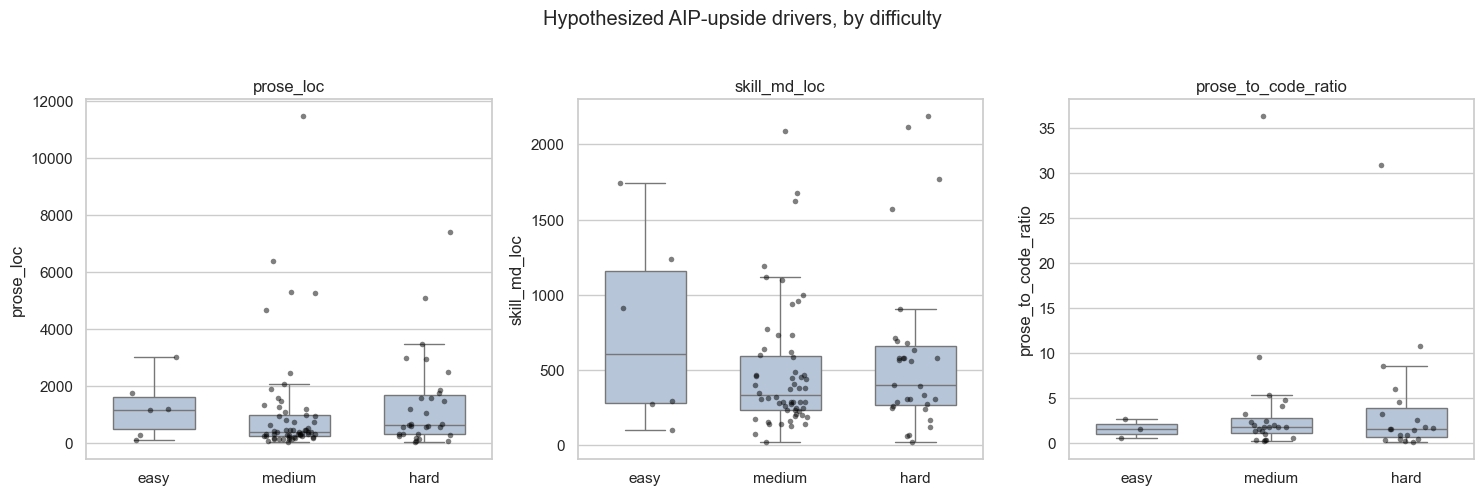

medians by difficulty:
  prose_loc            easy=1167.0  medium=399.5  hard=636.0
  skill_md_loc         easy=605.0  medium=335.5  hard=402.0
  prose_to_code_ratio  easy=1.5  medium=1.8  hard=1.6

prose_to_code_ratio panel covers 45/95 tasks (prose-only excluded).


In [5]:
order = ["easy", "medium", "hard"]
box_metrics = ["prose_loc", "skill_md_loc", "prose_to_code_ratio"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, metric in zip(axes, box_metrics):
    d = df.copy()
    d[metric] = pd.to_numeric(d[metric], errors="coerce")
    sub = d.dropna(subset=[metric])
    sns.boxplot(data=sub, x="difficulty", y=metric, order=order, ax=ax,
                color="lightsteelblue", fliersize=0, width=0.6)
    sns.stripplot(data=sub, x="difficulty", y=metric, order=order, ax=ax,
                  color="black", alpha=0.5, size=4, jitter=0.2)
    ax.set_title(metric)
    ax.set_xlabel("")
fig.suptitle("Hypothesized AIP-upside drivers, by difficulty", y=1.03)
plt.tight_layout()
plt.show()

# medians by difficulty + coverage note for the ratio panel
print("medians by difficulty:")
for m in box_metrics:
    s = df.assign(_v=pd.to_numeric(df[m], errors="coerce")).groupby("difficulty")["_v"].median().reindex(order)
    print(f"  {m:20s} easy={s['easy']:.1f}  medium={s['medium']:.1f}  hard={s['hard']:.1f}")
n_ratio = pd.to_numeric(df["prose_to_code_ratio"], errors="coerce").notna().sum()
print(f"\nprose_to_code_ratio panel covers {n_ratio}/{len(df)} tasks (prose-only excluded).")

## ln-transformed drivers: scatter + regression

The three hypothesized AIP-upside drivers (`prose_loc`, `skill_md_loc`, `prose_to_code_ratio`) are heavy-tailed, so a **natural-log transform** makes their pairwise relationships closer to linear and the OLS lines interpretable.

Two caveats:
- `prose_to_code_ratio` is undefined for the **50 prose-only tasks** (no scripts), so this matrix covers only the **45 with-scripts tasks** (mixed + script-heavy).
- By construction `ln(prose_to_code_ratio) = ln(prose_loc) − ln(script_loc)`, so `ln_prose_to_code_ratio` shares the `prose_loc` term with `ln_prose_loc` — expect some built-in positive association between those two.

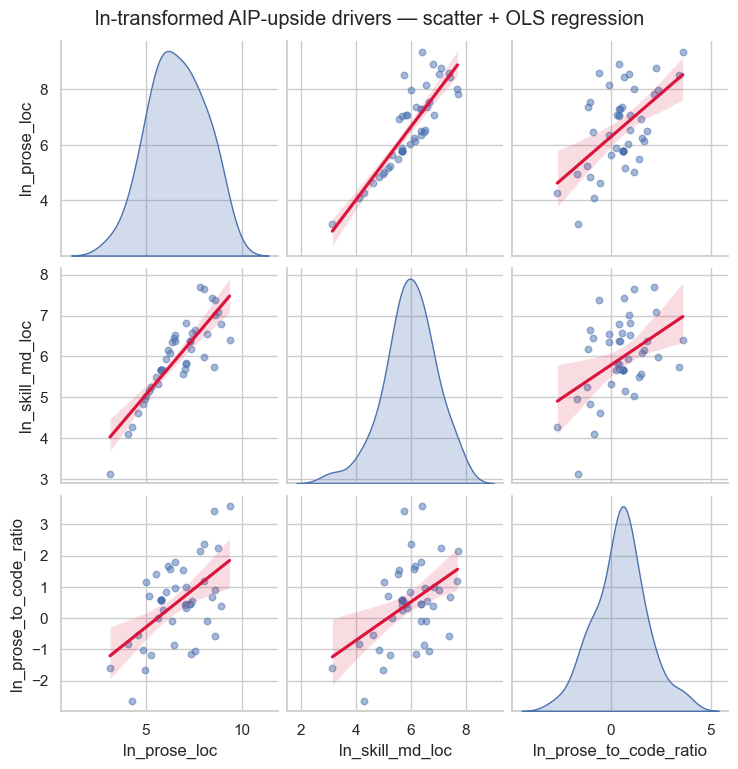

n = 45 tasks (all three defined; 50 prose-only excluded — no ratio)

Pearson correlation on the log scale:
                        ln_prose_loc  ln_skill_md_loc  ln_prose_to_code_ratio
ln_prose_loc                    1.00             0.85                    0.55
ln_skill_md_loc                 0.85             1.00                    0.45
ln_prose_to_code_ratio          0.55             0.45                    1.00


In [6]:
log_src = ["prose_loc", "skill_md_loc", "prose_to_code_ratio"]
logdf = pd.DataFrame({f"ln_{m}": np.log(pd.to_numeric(df[m], errors="coerce")) for m in log_src})
logdf = logdf.replace([np.inf, -np.inf], np.nan).dropna()

g = sns.pairplot(logdf, kind="reg", diag_kind="kde",
                 plot_kws={"line_kws": {"color": "crimson"},
                           "scatter_kws": {"alpha": 0.5, "s": 22}})
g.figure.suptitle("ln-transformed AIP-upside drivers — scatter + OLS regression", y=1.02)
plt.show()

print(f"n = {len(logdf)} tasks (all three defined; 50 prose-only excluded — no ratio)\n")
print("Pearson correlation on the log scale:")
print(logdf.corr().round(2))

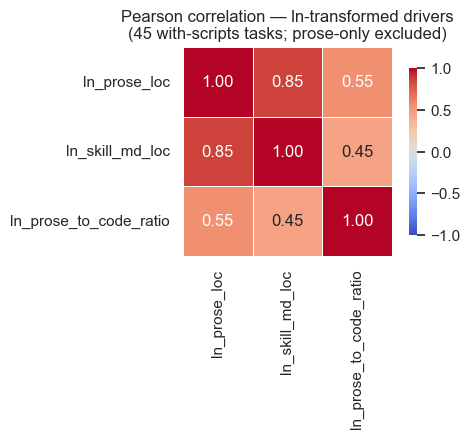

In [7]:
# Correlation heatmap of the ln-transformed drivers (reuses logdf from the cell above)
log_corr = logdf.corr()
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(log_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Pearson correlation — ln-transformed drivers\n(45 with-scripts tasks; prose-only excluded)")
plt.tight_layout()
plt.show()

## Where the eval-3med tasks land on the `prose_loc` spectrum

Percentile rank of each tested task's `prose_loc` across all 95 tasks — to see how representative the 3-task run was of the AIP-upside axis.

,task,structure_class,difficulty,prose_loc,prose_loc_pctile
16,earthquake-plate-calculation,prose-only,medium,226,20.0
13,drone-planning-control,prose-only,medium,463,48.0
8,crystallographic-wyckoff-position-analysis,mixed,medium,6386,98.0


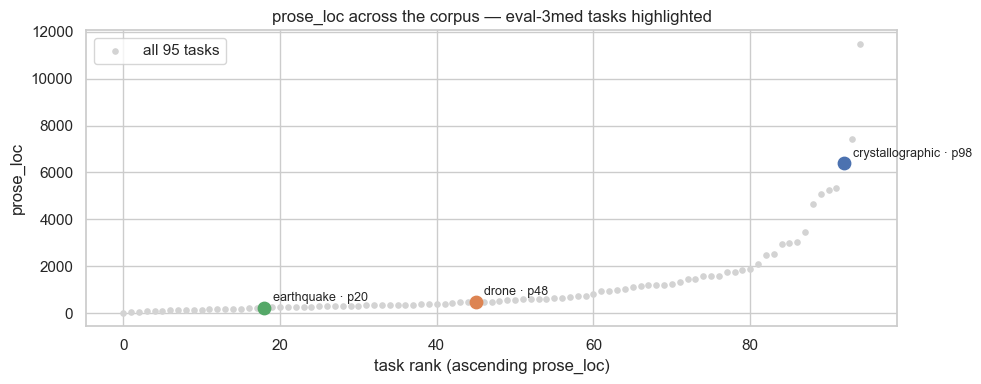

In [8]:
tested = ["crystallographic-wyckoff-position-analysis",
          "drone-planning-control", "earthquake-plate-calculation"]

d = df.copy()
d["prose_loc"] = pd.to_numeric(d["prose_loc"], errors="coerce")
d["prose_loc_pctile"] = (d["prose_loc"].rank(pct=True) * 100).round(0)

view = (d[d["task"].isin(tested)]
        [["task", "structure_class", "difficulty", "prose_loc", "prose_loc_pctile"]]
        .sort_values("prose_loc_pctile"))
display(view)

# all 95 sorted by prose_loc, the 3 tested tasks highlighted
ds = d.sort_values("prose_loc").reset_index(drop=True)
plt.figure(figsize=(10, 4))
plt.scatter(ds.index, ds["prose_loc"], s=14, color="lightgray", label="all 95 tasks")
for t in tested:
    row = ds[ds["task"] == t]
    pct = d.loc[d["task"] == t, "prose_loc_pctile"].iloc[0]
    plt.scatter(row.index, row["prose_loc"], s=80, zorder=5)
    plt.annotate(f"{t.split('-')[0]} · p{pct:.0f}",
                 (row.index[0], row["prose_loc"].iloc[0]),
                 textcoords="offset points", xytext=(6, 5), fontsize=9)
plt.xlabel("task rank (ascending prose_loc)")
plt.ylabel("prose_loc")
plt.title("prose_loc across the corpus — eval-3med tasks highlighted")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

### …and on the `prose_to_code_ratio` spectrum

Same view for `prose_to_code_ratio`, percentile-ranked across the **45 with-scripts tasks**. Note: `drone-planning-control` and `earthquake-plate-calculation` are **prose-only** (`script_loc = 0`) so they have *no* ratio — they effectively sit beyond the top of this axis (all prose, no code) and can't be plotted on it.

,task,structure_class,prose_to_code_ratio,ratio_pctile
0,crystallographic-wyckoff-position-analysis,mixed,9.52,93.0
1,drone-planning-control,prose-only,"— (prose-only, no scripts)",n/a
2,earthquake-plate-calculation,prose-only,"— (prose-only, no scripts)",n/a


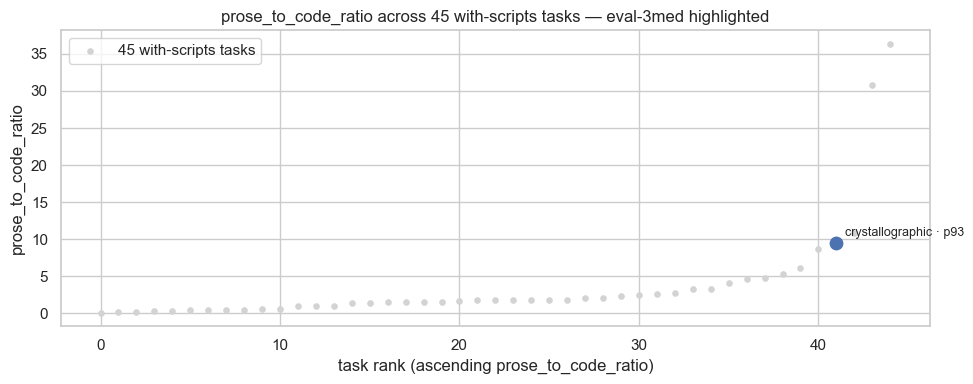

drone-planning-control & earthquake-plate-calculation are prose-only (no ratio) —
they sit beyond the top of this axis (all prose, no code) and are not plotted.


In [9]:
d = df.copy()
d["ratio"] = pd.to_numeric(d["prose_to_code_ratio"], errors="coerce")
have = d.dropna(subset=["ratio"]).copy()
have["ratio_pctile"] = (have["ratio"].rank(pct=True) * 100).round(0)

rows = []
for t in tested:
    r = d[d["task"] == t].iloc[0]
    if pd.isna(r["ratio"]):
        rows.append({"task": t, "structure_class": r["structure_class"],
                     "prose_to_code_ratio": "— (prose-only, no scripts)", "ratio_pctile": "n/a"})
    else:
        pc = have[have["task"] == t]["ratio_pctile"].iloc[0]
        rows.append({"task": t, "structure_class": r["structure_class"],
                     "prose_to_code_ratio": round(r["ratio"], 2), "ratio_pctile": pc})
display(pd.DataFrame(rows))

ds = have.sort_values("ratio").reset_index(drop=True)
plt.figure(figsize=(10, 4))
plt.scatter(ds.index, ds["ratio"], s=14, color="lightgray", label="45 with-scripts tasks")
for t in tested:
    row = ds[ds["task"] == t]
    if len(row):
        pc = have[have["task"] == t]["ratio_pctile"].iloc[0]
        plt.scatter(row.index, row["ratio"], s=80, zorder=5)
        plt.annotate(f"{t.split('-')[0]} · p{pc:.0f}",
                     (row.index[0], row["ratio"].iloc[0]),
                     textcoords="offset points", xytext=(6, 5), fontsize=9)
plt.xlabel("task rank (ascending prose_to_code_ratio)")
plt.ylabel("prose_to_code_ratio")
plt.title("prose_to_code_ratio across 45 with-scripts tasks — eval-3med highlighted")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()
print("drone-planning-control & earthquake-plate-calculation are prose-only (no ratio) —")
print("they sit beyond the top of this axis (all prose, no code) and are not plotted.")

## What to look for

- **`prose_loc` vs `script_loc`** — independent, or do verbose tasks also script more? Determines whether *prose-only* is a distinct regime AIP can target.
- **`difficulty_ord` correlations** — does structure track difficulty, or is it an independent axis? If independent, sample `structure_class` and `difficulty` separately.
- **`n_skills` vs LoC** — do multi-skill tasks carry proportionally more prose/code?

Use the separation in the colored matrix to choose eval tasks spanning the `structure_class` gradient (prose-only → script-heavy), with difficulty/category as secondary coverage.

## Implementation-complexity proxies

A task's *implementation burden* — how much code the agent must write/debug to act on a skill — is a second axis the structure metrics don't capture (two prose-only tasks, `earthquake-plate` and `drone`, sat at opposite ends of AIP benefit precisely because of this). SkillsBench gives a-priori proxies, added to `skill-metrics.csv`:

- **`agent_timeout_sec`** — the author's solver time budget (`[agent] timeout_sec` in `task.toml`).
- **`test_loc`** / **`test_files`** — verifier code size (more required outputs ⇒ more to implement).
- **`solution_loc`** — reference solution code size (weaker; reference solutions are terse).
- **`impl_class`** — heavy/light from `task_type` (`implementation`/`simulation`/`optimization`/`control` = heavy).

### Box plots by difficulty

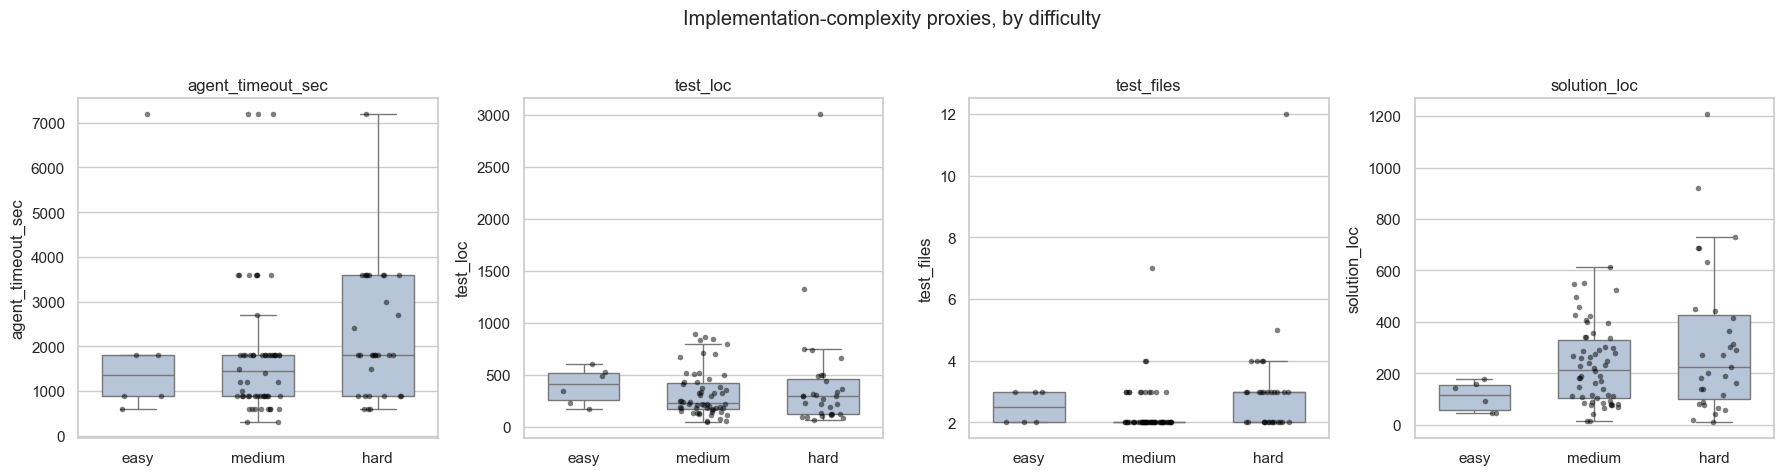

In [10]:
new_metrics = ["agent_timeout_sec", "test_loc", "test_files", "solution_loc"]
order = ["easy", "medium", "hard"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.6))
for ax, metric in zip(axes, new_metrics):
    d = df.copy()
    d[metric] = pd.to_numeric(d[metric], errors="coerce")
    sub = d[d[metric] > 0].dropna(subset=[metric])
    sns.boxplot(data=sub, x="difficulty", y=metric, order=order, ax=ax,
                color="lightsteelblue", fliersize=0, width=0.6)
    sns.stripplot(data=sub, x="difficulty", y=metric, order=order, ax=ax,
                  color="black", alpha=0.5, size=4, jitter=0.2)
    ax.set_title(metric)
    ax.set_xlabel("")
fig.suptitle("Implementation-complexity proxies, by difficulty", y=1.03)
plt.tight_layout()
plt.show()

### Do the two headline proxies agree? (log-log regression)

`agent_timeout_sec` (author's time budget) vs `test_loc` (verifier size) — if they correlate, they're measuring the same underlying implementation burden from two independent angles, which strengthens using either as the sampling axis.

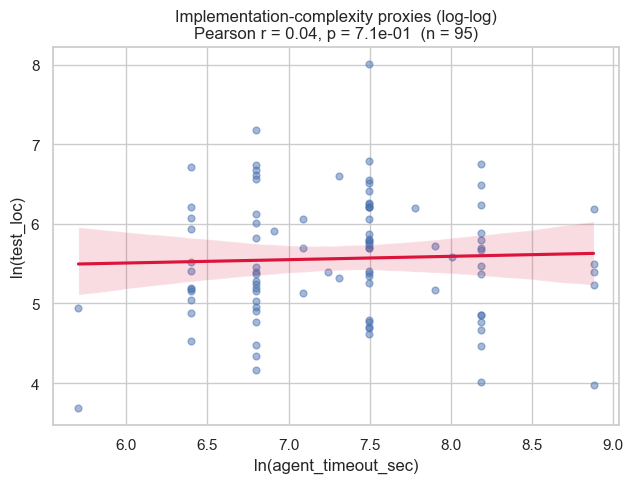

ln(agent_timeout_sec) vs ln(test_loc):  Pearson r = 0.039,  p = 7.06e-01,  n = 95


In [11]:
from scipy import stats

d = df.copy()
for c in ["agent_timeout_sec", "test_loc"]:
    d[c] = pd.to_numeric(d[c], errors="coerce")
sub = d[(d["agent_timeout_sec"] > 0) & (d["test_loc"] > 0)].dropna(subset=["agent_timeout_sec", "test_loc"])
x, y = np.log(sub["agent_timeout_sec"]), np.log(sub["test_loc"])
r, p = stats.pearsonr(x, y)

plt.figure(figsize=(6.5, 5))
sns.regplot(x=x, y=y, line_kws={"color": "crimson"}, scatter_kws={"alpha": 0.5, "s": 24})
plt.xlabel("ln(agent_timeout_sec)")
plt.ylabel("ln(test_loc)")
plt.title(f"Implementation-complexity proxies (log-log)\nPearson r = {r:.2f}, p = {p:.1e}  (n = {len(sub)})")
plt.tight_layout()
plt.show()
print(f"ln(agent_timeout_sec) vs ln(test_loc):  Pearson r = {r:.3f},  p = {p:.2e},  n = {len(sub)}")

---

## Finding: structure is necessary but not sufficient — implementation burden is the second axis

The eval-3med run exposed a gap in these metrics. `earthquake-plate-calculation` and `drone-planning-control` are **both prose-only** at similar low/mid `prose_loc` (p20 vs p48), yet AIP-from-curated's benefit over human-curated was **opposite**:

| | earthquake-plate | drone-planning |
|---|---|---|
| `structure_class` / `prose_loc` pctile | prose-only / p20 | prose-only / p48 |
| human-curated baseline | **5/5**, 80–104 s, 6–12 tools | **2/5**, 1059–1705 s, 12–31 tools (one 21-min stall) |
| AIP-cur outcome | 5/5 — **no advantage** | 5/5 — **the whole win** |
| script LoC AIP conversion added | 180 | **1,377** |
| `task_type` | calculation, analysis | implementation, simulation, optimization |

**Interpretation.** `structure_class` measures the *room* to add executability (prose-only = lots of room). But the *benefit* of adding it also depends on how costly/error-prone it is to act on the prose:

> **AIP-cur benefit ≈ (room to add executability) × (implementation burden of the task).**

- `earthquake-plate` is a short deterministic pipeline (project → distance → max) — easy to execute correctly from prose, so the human prose skill already sufficed and AIP's 180 LoC added nothing.
- `drone` requires building *and tuning* a multi-component control system in simulation — high implementation burden, error-prone from prose (human 2/5, one stall), so AIP's 1,377 LoC of vetted scripts removed the burden and won.

**Design implication.** Sampling on `structure_class` alone is not enough; cross it with **implementation burden**, proxied by:
- *a-priori*: `task_type` — `implementation` / `simulation` / `optimization` / `control` = heavy; `calculation` / `extraction` / `analysis` / `classification` = light.
- *empirical*: the noskill/human baseline's wall-clock, tool calls, and variance (run a screen).
- *post-conversion*: AIP-cur script LoC (how much code Opus deemed necessary).

The cleanest next experiment is a **2×2 of `structure_class` × implementation-burden**: a prose-only *calculation* task is the predicted **null** (AIP ≈ human, like earthquake-plate); a prose-only *simulation/implementation* task is the predicted **big win** (like drone). Showing both ends makes the gradient credible.

---

## Proposed eval sample — 24 tasks, stratified

Starter sample for the *human-curated vs AIP-from-curated* experiment, stratified to **maximize variance across the candidate predictors** so the benefit regression can discriminate which (if any) actually drives AIP uplift — deliberately *not* keyed to a single assumed driver.

- **Grid:** `structure_class` (prose-only / mixed / script-heavy) × `impl_class` (heavy / light) = 6 cells. Prose-only cells get 5 each (the highest predicted-upside regime); `script-heavy × heavy` is capped at 3 (only 3 such tasks exist in the corpus).
- **`impl_class` is the unvalidated `task_type` heuristic** (n=2 evidence). It's used here **only as a coverage lever**, not as the measured driver. True implementation burden will be measured empirically from the `noskill` baseline (authoring effort: `Write`/`Edit` counts, wall, iteration) and entered in the regression alongside `prose_loc`, `agent_timeout_sec`, `test_loc`.
- **Difficulty (5 easy / 10 medium / 9 hard) and category (7 domains)** are spanned as covariates, not selection axes — difficulty is ~independent of structure (see heatmap).
- **Excludes the 3 eval-3med tasks** (drone-planning-control, earthquake-plate-calculation, crystallographic-wyckoff-position-analysis) — fresh tasks only. **All 24 need `aip-from-curated` conversion** against the current AIP spec before running.
- **Run:** `noskill` / `human-curated` / `aip-from-curated`, n ≥ 10, Sonnet.

In [12]:
# Proposed 24-task stratified sample (structure_class × impl_class grid)
eval24 = {
    "prose-only × heavy": ["energy-unit-commitment", "adaptive-cruise-control",
                            "mars-clouds-clustering", "bike-rebalance", "parallel-tfidf-search"],
    "prose-only × light": ["offer-letter-generator", "fix-build-google-auto",
                           "exoplanet-detection-period", "spring-boot-jakarta-migration",
                           "enterprise-information-search"],
    "mixed × heavy":      ["energy-market-pricing", "grid-dispatch-operator",
                           "jax-computing-basics", "suricata-custom-exfil"],
    "mixed × light":      ["court-form-filling", "powerlifting-coef-calc",
                           "dapt-intrusion-detection", "protein-expression-analysis"],
    "script-heavy × heavy": ["data-to-d3", "dialogue-parser", "civ6-adjacency-optimizer"],
    "script-heavy × light": ["3d-scan-calc", "sec-financial-report", "travel-planning"],
}
recs = []
for cell, tasks in eval24.items():
    for t in tasks:
        r = df[df["task"] == t].iloc[0]
        recs.append({"cell": cell, "task": t, "difficulty": r["difficulty"],
                     "category": r["category"],
                     "prose_loc": int(pd.to_numeric(r["prose_loc"])),
                     "script_loc": int(pd.to_numeric(r["script_loc"])),
                     "agent_timeout_sec": r["agent_timeout_sec"], "test_loc": r["test_loc"]})
sample_df = pd.DataFrame(recs)
display(sample_df)
print("n =", len(sample_df))
print("difficulty:", sample_df["difficulty"].value_counts().to_dict())
print("categories:", sample_df["category"].nunique(), sample_df["category"].value_counts().to_dict())
print("per cell:", sample_df["cell"].value_counts().to_dict())

,cell,task,difficulty,category,prose_loc,script_loc,agent_timeout_sec,test_loc
0,prose-only × heavy,energy-unit-commitment,hard,industrial-physical-systems,582,0,900.0,750
1,prose-only × heavy,adaptive-cruise-control,medium,industrial-physical-systems,450,0,1800.0,502
2,prose-only × heavy,mars-clouds-clustering,hard,natural-science,312,0,3600.0,129
3,prose-only × heavy,bike-rebalance,medium,mathematics-or-formal-reasoning,998,0,900.0,792
4,prose-only × heavy,parallel-tfidf-search,medium,software-engineering,1338,0,1800.0,210
5,prose-only × light,offer-letter-generator,easy,office-white-collar,274,0,900.0,173
6,prose-only × light,fix-build-google-auto,easy,software-engineering,1741,0,1800.0,607
7,prose-only × light,exoplanet-detection-period,medium,natural-science,1101,0,3600.0,107
8,prose-only × light,spring-boot-jakarta-migration,hard,software-engineering,1571,0,900.0,190
9,prose-only × light,enterprise-information-search,hard,office-white-collar,252,0,1800.0,109


n = 24
difficulty: {'medium': 10, 'hard': 9, 'easy': 5}
categories: 7 {'software-engineering': 6, 'industrial-physical-systems': 5, 'office-white-collar': 4, 'natural-science': 3, 'mathematics-or-formal-reasoning': 3, 'cybersecurity': 2, 'finance-economics': 1}
per cell: {'prose-only × heavy': 5, 'prose-only × light': 5, 'mixed × heavy': 4, 'mixed × light': 4, 'script-heavy × heavy': 3, 'script-heavy × light': 3}
